<a href="https://colab.research.google.com/github/3dgarxx3/Mineria_Datos/blob/main/TercerParcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tercer Parcial

## K‑Nearest Neighbors (K-NN) k vecinos más cercanos

###Ejercicio 1: k‑NN manual (k = 1, distancia euclidiana)

####Datos

In [ ]:
import math

# Datos de entrenamiento
X = [(2,4), (4,4), (4,2), (6,2)]
y = ['Rojo', 'Rojo', 'Azul', 'Azul']

# Punto a clasificar
P = (3, 3)

####Función de distancia euclidiana

In [ ]:
def distancia_euclidiana(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

####Cálculo del vecino más cercano

In [ ]:
distancias = []
for i in range(len(X)):
    d = distancia_euclidiana(P, X[i])
    distancias.append((d, y[i]))

# Ordenar por distancia
distancias.sort(key=lambda x: x[0])

print(distancias)
print("Clase asignada:", distancias[0][1])

[(1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Azul'), (3.1622776601683795, 'Azul')]
Clase asignada: Rojo


###Ejercicio 2: k‑NN manual con k = 3

In [ ]:
from collections import Counter

k = 3
vecinos = distancias[:k]

clases = [clase for _, clase in vecinos]
resultado = Counter(clases).most_common(1)

print("Vecinos:", vecinos)
print("Clase asignada:", resultado[0][0])


Vecinos: [(1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Azul')]
Clase asignada: Rojo


### Ejercicio 3: Distancia Manhattan

In [ ]:
def distancia_manhattan(p1, p2):
    return abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])

X = [(1,1), (2,3), (5,4), (6,5)]
y = ['Baja', 'Baja', 'Alta', 'Alta']
P = (4,3)

distancias = []

for i in range(len(X)):
    d = distancia_manhattan(P, X[i])
    distancias.append((d, y[i]))

distancias.sort(key=lambda x: x[0])

print(distancias)
print("Clase asignada:", distancias[0][1])

[(2, 'Baja'), (2, 'Alta'), (4, 'Alta'), (5, 'Baja')]
Clase asignada: Baja


###Ejercicio 4: k‑NN con scikit-learn

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

####Datos tipo Iris (reducido)

In [ ]:
X = np.array([
[5.1, 3.5],
[4.9, 3.0],
[6.2, 3.4],
[6.0, 2.9]
])

y = np.array(['Setosa', 'Setosa', 'Versicolor', 'Versicolor'])

P = np.array([[5.8, 3.2]])

####Entrenamiento y predicción

In [ ]:
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X, y)

prediccion = modelo.predict(P)
print("Clase predicha:", prediccion[0])

Clase predicha: Versicolor


###Ejercicio K-NN

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Cargar el dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Separación de datos: 80% Entrenamiento, 20% Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de prueba: {len(X_test)}")

Muestras de entrenamiento: 120
Muestras de prueba: 30


####¿Que es el codo?

 es una técnica gráfica utilizada en Machine Learning para encontrar el número óptimo de grupos (k) al usar el algoritmo de agrupamiento K-Means

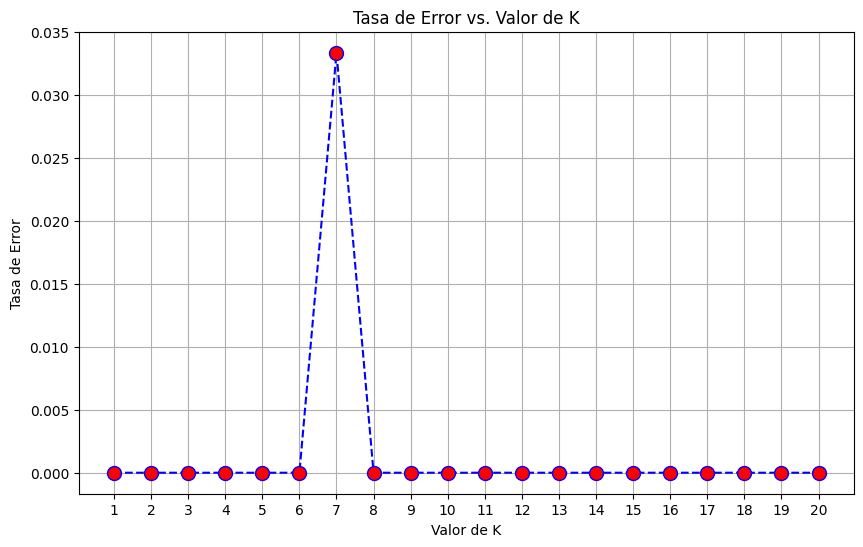

In [ ]:
# Lista para almacenar las tasas de error
error_rate = []

# Probar valores de k del 1 al 20
for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    # Calculamos el promedio de donde la predicción no fue igual al valor real
    error_rate.append(np.mean(pred_i != y_test))

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Tasa de Error vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Tasa de Error')
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()